# Practice 4: MCP (Model Context Protocol)

> "많은 엔지니어들이 MCP를 단순한 '도구 호출용 프로토콜'로 오해하곤 합니다. <br>
> 하지만 MCP는 **모듈형 에이전트 시스템을 구축하기 위한 아키텍처** 그 자체입니다."

---

## MCP 연동 가이드 및 주의사항

### 보안 핵심 원칙
- **공급망 보안**: `npm`등 외부 패키지 설치 시 반드시 신뢰할 수 있는 출처인지 확인하세요.
- **자격 증명 관리**: OAuth 토큰, API 키 등을 코드 내에 하드코딩 하면 안됩니다.
- **서버 신뢰성 검증**: 검증되지 않은 써드파티 MCP 서버는 실행 환경의 데이터를 탈취할 수 있으므로 주의가 필요합니다.
    

### 보안 위협 및 취약점 참고 사례
- **React2Shell**: [React·Next.js서 심각도 10 취약점 발견... 인증 없이 원격 코드 실행 가능](https://sslc.kr/board/news/1190)

## 원격 코드 취약점 대응
`npx fix-react2shell-next`

## 환경 설정

- 취약한 버전의 React/Next.js를 안전한 버전으로 강제 업데이트
    - 공격자가 서버의 제어권을 탈취할 수 있는 React2Shell 취약점을 방지하기 위해 해당 코드를 실행합니다.

In [1]:
! npx -y fix-react2shell-next

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
fix-react2shell-next - Next.js vulnerability scanner

Checking for 4 known vulnerabilities:

  - CVE-2025-66478 (critical): Remote code execution via crafted RSC payload
  - CVE-2025-55184 (high): DoS via malicious HTTP request causing server to hang and consume CPU
  - CVE-2025-55183 (medium): Compiled Server Action source code can be exposed via malicious request
  - CVE-2025-67779 (high): Incomplete fix for CVE-2025-55184 DoS via malicious RSC payload causing infinite loop

No package.json files found in current directory.

⠙

- 실습 환경 구축을 위한 패키지 설치

In [2]:
!pip install langgraph langchain-upstage langchain==1.1.3 rich langchain-mcp-adapters tavily-python fastmcp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.2/416.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.8/197.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.3/96.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.8/295.8 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0

- Google Colab의 '보안 비밀번호(Secrets)' 메뉴에 등록한 API KEY를 환경 변수로 불러옵니다.

- TODOIST_API_TOKEN 발급 (실습 코드의 설명 참고)
    - https://app.todoist.com/app/onboard/welcome
- TAVILY_API_KEY 발급 (실습 코드의 설명 참고)
    - https://www.tavily.com/

In [3]:
import os
from google.colab import userdata

# 설정할 키 목록
keys = [
    'LANGSMITH_API_KEY', 'UPSTAGE_API_KEY', 'TAVILY_API_KEY', 'TODOIST_API_TOKEN'
]

for key in keys:
    try:
        os.environ[key] = userdata.get(key)
    except:
        print(f"경고: {key}를 '보안 비밀번호'에서 찾을 수 없습니다.")

# 고정값 설정
os.environ["LANGSMITH_TRACING_V2"] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = 'agentic-workflow'

- 실습에 필요한 라이브러리 로드 및 LLM 모델 초기화

In [4]:
from rich import print as rprint
from langchain.chat_models import init_chat_model

MODEL = "solar-pro2"
llm = init_chat_model(
    model=MODEL,
    temperature=0.0
)

## LangChain MCP Adapters
- https://github.com/langchain-ai/langchain-mcp-adapters
- Anthropic Model Context Protocol(MCP) 도구가 LangChain 및 LangGraph와 호환되도록 하는 경량 래퍼입니다.
<!-- Langchain MCP 구조 다이어그램 표시 -->
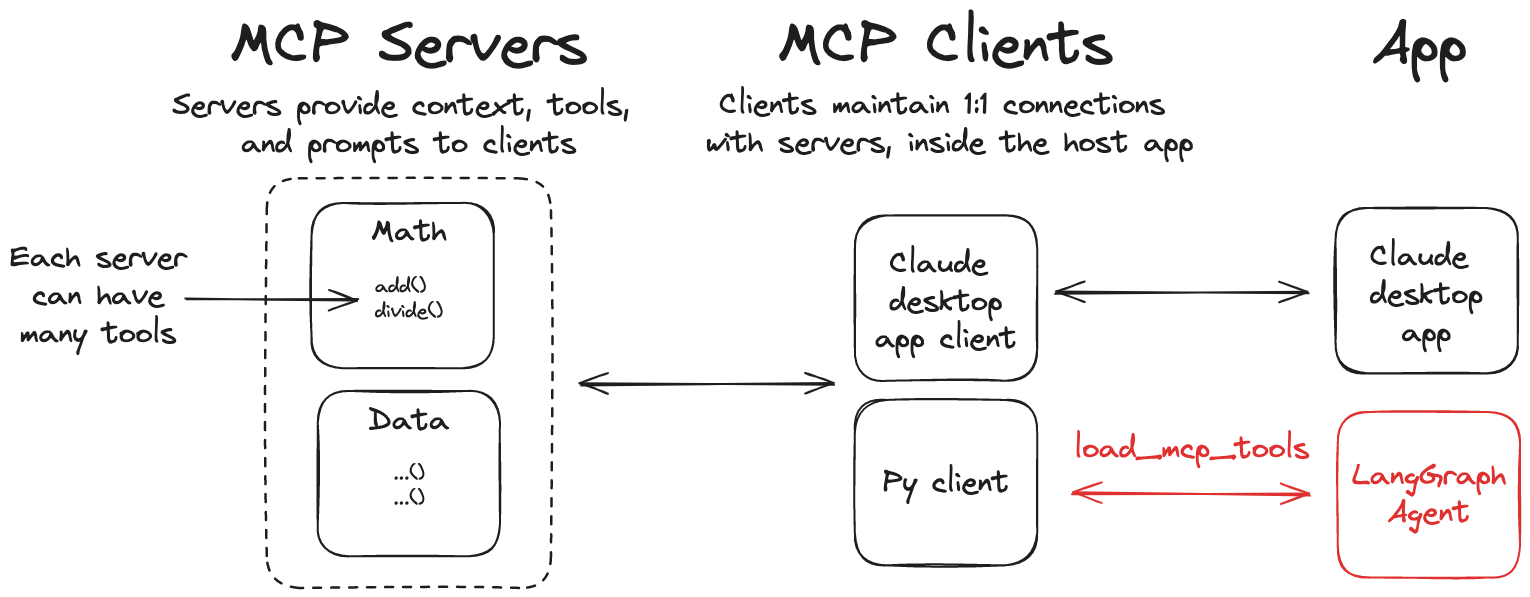

### STDIO

- [**stdio**](https://modelcontextprotocol.io/specification/2025-06-18/basic/transports#stdio)
    - 파이썬(클라이언트)과 MCP 서버가 별도의 네트워크 설정 없이, 표준 입출력 통로를 통해 직접 데이터를 주고받는 로컬 통신 방식입니다.
    - npx command를 사용하면, MCP 서버 프로그램을 미리 설치해두지 않아도, 실행 시점에 원격 저장소에서 즉시 내려받아 임시로 구동해줍니다.
    - 만약 다운 받은 캐시를 지우고 싶다면, `sudo npm cache clean --force` 을 실행하여 줍니다.
    - 캐시에서 버전이 꼬여 문제가 발생하였다면, `npm cache verify`를 통해 해결하여줍니다.


- 코랩에서는 MCP 서버와 통신하기 위해 파일 식별자 번호를 임의로 붙여줍니다.

In [5]:
import sys
import nest_asyncio

# 표준 입력 / 표준 출력 / 표준 에러에 대해 식별자를 달아줍니다.
sys.stdin.fileno = lambda: 0
sys.stdout.fileno = lambda: 1
sys.stderr.fileno = lambda: 2

nest_asyncio.apply() # 비동기 코드가 자동 가능하도록 허용

#### 단일 MCP 호출하여 사용해보기
- 시간대 인식 기능을 위한 mcp-time 서버
    - 이 Go 기반 서버는 현재 시간 조회, 상대적 시간 파싱, 시간대 변환, 기간 산술 연산, 시간 비교 등의 도구를 제공합니다.
    - https://github.com/TheoBrigitte/mcp-time/tree/main

In [6]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# https://github.com/TheoBrigitte/mcp-time/tree/main
mcp_client = MultiServerMCPClient(
    {
        "time": {
            "transport": "stdio",
            "command": "npx",
            "args": ["-y", "@theo.foobar/mcp-time"],
        }
    },
)

# Load tools from the MCP server
mcp_tools = await mcp_client.get_tools()
print(f"Loaded {len(mcp_tools)} MCP tools: {[t.name for t in mcp_tools]}")

Loaded 5 MCP tools: ['add_time', 'compare_time', 'convert_timezone', 'current_time', 'relative_time']


In [7]:
from langchain.agents import create_agent

agent_with_mcp = create_agent(
    model=llm,
    tools=mcp_tools,
    system_prompt="You are a helpful assistant",
)

result = await agent_with_mcp.ainvoke(
    {"messages": [{"role": "user", "content": "현재 한국의 시간은 몇 시인가요?"}]}
)
for msg in result["messages"]:
    rprint(msg)

HumanMessage(
    content='현재 한국의 시간은 몇 시인가요?',
    additional_kwargs={},
    response_metadata={},
    id='ed46e299-2c29-4016-8106-b1be6f438649'
)

AIMessage(
    content='[현재 한국 시간을 확인하기 위해 `current_time` 함수를 호출했습니다. 필수 매개변수인 `timezone`을 
"Asia/Seoul"로 설정하고, 시간 형식(`format`)을 "15:04:05"로 지정하여 시:분:초만 출력하도록 했습니다. 이 함수 호출은
질문에 직접적이고 필수적입니다.]',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 97,
            'prompt_tokens': 2286,
            'total_tokens': 2383,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'solar-pro2-251215',
        'system_fingerprint': None,
        'id': 'ce4cddf6-d4a8-457c-abb0-3f9280c3cbde',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019bbabf-697a-7440-af6f-f6eb9aaeaa81-0',
    tool_calls=[
        {
            'name': 'current_time',
            'args': {'timezone': 'Asia/Seoul', 'format': '15:04:05'},
            'id': 'chatcmpl-tool-e1d43556a54e41b28b7260ff30581d98',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 2286,
        'output_tokens': 97,
        'total_tokens': 2383,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

ToolMessage(
    content=[{'type': 'text', 'text': '13:24:29', 'id': 'lc_bb048db0-ac21-48b6-b1bd-2c5991cb1766'}],
    name='current_time',
    id='a316a91e-5bd8-4b6b-8c62-19e9a570722a',
    tool_call_id='chatcmpl-tool-e1d43556a54e41b28b7260ff30581d98'
)

AIMessage(
    content='현재 한국 시간은 **13:24:29**입니다. (UTC+9, 서울 기준)  \n\n(참고: 실제 시간은 함수 호출 시점에 따라 
달라질 수 있습니다.)',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 38,
            'prompt_tokens': 2405,
            'total_tokens': 2443,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'solar-pro2-251215',
        'system_fingerprint': None,
        'id': 'eb9f363e-a42a-476c-8dc5-ab3cc958cf73',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019bbabf-7864-7563-a41a-9796eb33a103-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 2405,
        'output_tokens': 38,
        'total_tokens': 2443,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

#### 다중 MCP 연결하여 실행해보기
- **Todoist MCP**: 모든 계획 수립과 작업 생성을 MCP를 통해 처리할 수 있는 Todoist MCP를 소개합니다.
- https://github.com/abhiz123/todoist-mcp-server
- 선행 작업: https://app.todoist.com/app/onboard/welcome 가입
- 결제 창이 뜨면 꺼주시고 설정에서 API를 검색하여 API Key를 가져와 줍니다. (결제하지 않아도 비기너 플랜으로 무료로 사용하실 수 있습니다.)
- 아래 env에 넣어줍니다.

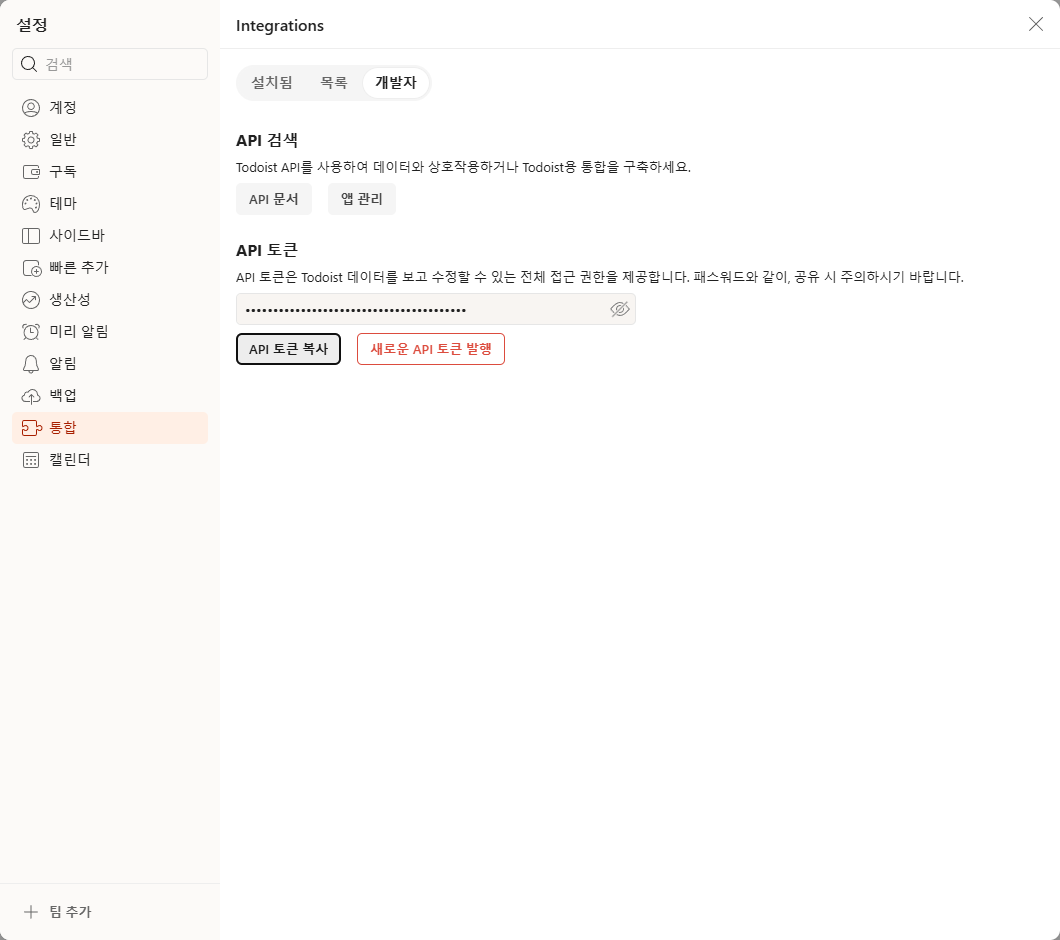

In [8]:
import os
mcp_client = MultiServerMCPClient(
    {
        "time": {
            "transport": "stdio",
            "command": "npx",
            "args": ["-y", "@theo.foobar/mcp-time"],
        },
        "todoist": {
            "transport": "stdio",
            "command": "npx",
            "args": ["-y", "@abhiz123/todoist-mcp-server"],
            "env": {
                "TODOIST_API_TOKEN": os.environ.get("TODOIST_API_TOKEN")
            }
        }
    }
)
# Load tools from the MCP server
mcp_tools = await mcp_client.get_tools()
print(f"Loaded {len(mcp_tools)} MCP tools: {[t.name for t in mcp_tools]}")

Loaded 10 MCP tools: ['add_time', 'compare_time', 'convert_timezone', 'current_time', 'relative_time', 'todoist_create_task', 'todoist_get_tasks', 'todoist_update_task', 'todoist_delete_task', 'todoist_complete_task']


In [9]:
from langchain.agents import create_agent

agent_with_mcp = create_agent(
    model=llm,
    tools=mcp_tools,
    system_prompt="You are a helpful assistant",
)

result = await agent_with_mcp.ainvoke(
    {"messages": [
            {
                "role": "user",
                "content": "내일이 몇 월 며칠이지? \
내일 오전 10시에 'MCP 강의 자료 만들기'라는 할 일을 추가해줘."
            },
        ]
    }
)
for msg in result["messages"]:
    rprint(msg)

HumanMessage(
    content="내일이 몇 월 며칠이지? 내일 오전 10시에 'MCP 강의 자료 만들기'라는 할 일을 추가해줘.",
    additional_kwargs={},
    response_metadata={},
    id='c2dde7ca-e51d-4a48-9cd0-0d32eb4bd151'
)

AIMessage(
    content='[1. `current_time`으로 오늘 날짜를 확인하고, 2. `relative_time`으로 내일 날짜를 정확히 계산한 후, 3. 
`todoist_create_task`로 내일 오전 10시에 할 일을 추가합니다. 모든 함수 호출은 질문에 직접 필요한 정보를 제공하기 
위해 필수적입니다.]  \n\n### 추가 설명  \n- `current_time`과 `relative_time`은 내일 날짜를 명확히 확인하기 위해 
사용되었습니다.  \n- `todoist_create_task`는 "내일 오전 10시"라는 구체적인 시간을 반영하기 위해 
`due_string="tomorrow at 10am"`으로 설정했습니다.  \n- 우선순위는 기본값(1)보다 높은 2로 지정했습니다. 필요 시 조정
가능합니다.',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 226,
            'prompt_tokens': 3037,
            'total_tokens': 3263,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 432}
        },
        'model_provider': 'openai',
        'model_name': 'solar-pro2-251215',
        'system_fingerprint': None,
        'id': 'b7ae4262-5f2a-49b4-b3c3-387d86b138bf',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019bbac4-64a8-71e2-8ad1-72395545df28-0',
    tool_calls=[
        {
            'name': 'current_time',
            'args': {'format': '2006-01-02', 'timezone': 'Asia/Seoul'},
            'id': 'chatcmpl-tool-0f0e0b62238941feaae6175f390b44ce',
            'type': 'tool_call'
        },
        {
            'name': 'relative_time',
            'args': {'text': 'tomorrow', 'format': '2006-01-02', 'timezone': 'Asia/Seoul'},
            'id': 'chatcmpl-tool-782e9e8458c740da8c2cdcd947b83cbe',
            'type': 'tool_call'
        },
        {
            'name': 'todoist_create_task',
            'args': {'content': 'MCP 강의 자료 만들기', 'due_string': 'tomorrow at 10am', 'priority': 2},
            'id': 'chatcmpl-tool-ba5f9267c1264121996f378a105acb08',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 3037,
        'output_tokens': 226,
        'total_tokens': 3263,
        'input_token_details': {'audio': 0, 'cache_read': 432},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

ToolMessage(
    content=[{'type': 'text', 'text': '2026-01-14', 'id': 'lc_dccb9701-e188-486c-ad9f-963dee9acac1'}],
    name='current_time',
    id='978daea1-42b9-4669-a8ec-d4b84dad5566',
    tool_call_id='chatcmpl-tool-0f0e0b62238941feaae6175f390b44ce'
)

ToolMessage(
    content=[{'type': 'text', 'text': '2026-01-15', 'id': 'lc_4ffe91df-6f21-4a49-807c-e23764d38919'}],
    name='relative_time',
    id='18ebdce1-9674-46c9-b7cd-4d7e24067613',
    tool_call_id='chatcmpl-tool-782e9e8458c740da8c2cdcd947b83cbe'
)

ToolMessage(
    content=[
        {
            'type': 'text',
            'text': 'Task created:\nTitle: MCP 강의 자료 만들기\nDue: tomorrow at 10am\nPriority: 2',
            'id': 'lc_a58cd534-0e38-491d-9daf-f0823467e5e3'
        }
    ],
    name='todoist_create_task',
    id='77a76fe8-d604-43b5-9459-5a72d70422d2',
    tool_call_id='chatcmpl-tool-ba5f9267c1264121996f378a105acb08'
)

AIMessage(
    content='내일은 **2026년 1월 15일**입니다.  \n할 일이 성공적으로 추가되었습니다:  \n\n- **제목**: MCP 강의 자료
만들기  \n- **마감일**: 내일 오전 10시 (2026-01-15 10:00)  \n- **우선순위**: 2  \n\nTodoist에서 확인 및 관리할 수 
있습니다. 😊',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 88,
            'prompt_tokens': 3334,
            'total_tokens': 3422,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'solar-pro2-251215',
        'system_fingerprint': None,
        'id': '265dcdf8-cc8d-4cde-a539-06187b643816',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019bbac4-83c0-7050-afd3-5a770b976c5c-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 3334,
        'output_tokens': 88,
        'total_tokens': 3422,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

- "내일 오전 10시에 'MCP 강의 자료 만들기'라는 할 일을 추가해줘." 실행 결과 (https://app.todoist.com/app/inbox)

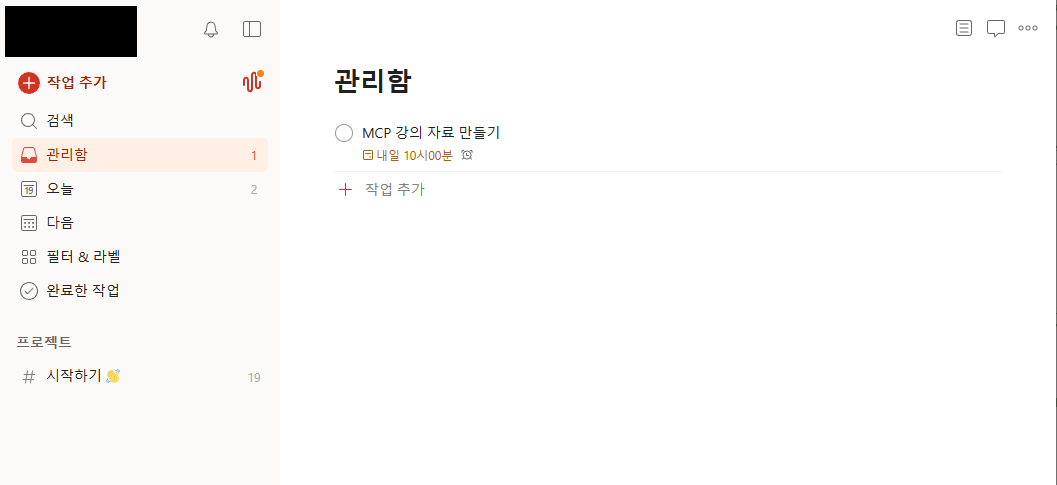


### Streamable HTTP

 - **[Streamable HTTP](https://modelcontextprotocol.io/specification/2025-06-18/basic/transports#streamable-http)**
     - 로컬 프로세스 실행 방식인 stdio와 달리, 네트워크 상의 원격 서버에 있는 MCP 서버와 통신할 때 사용하는 방식입니다.
     - **편의성**: 로컬 자원을 사용하지 않고도 클라우드나 원격 서버에 구축된 도구(Tools) 및 데이터(Resources)를 **API 연동 방식**으로 에이전트에 즉시 통합할 수 있습니다.
     - **확장성**: 독립된 서버가 다수의 클라이언트를 동시에 수용하며, **SSE(Server-Sent Events)** 기반의 실시간 스트리밍을 통해 효율적인 서버-클라이언트 아키텍처를 구현합니다.
     - **보안 설정**: 외부로 기능이 노출되는 원격 환경 특성상, **OAuth 2.1** 등 인증 레이어를 적용하여 도구 접근 및 실행 권한을 통제합니다.


- LangGraph Docs
    - https://docs.langchain.com/ (Docs)
    - https://docs.langchain.com/mcp
```json
{
  "server": {
    "name": "Docs by LangChain",
    "version": "1.0.0",
    "transport": "http"
  },
  "capabilities": {
    "tools": [
      {
        "name": "SearchDocsByLangChain",
        "description": "Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages.",
        "inputSchema": {
          "type": "object",
          "properties": {
            "query": {
              "type": "string",
              "description": "A query to search the content with."
            }
          },
          "required": ["query"]
        },
        "operationId": "MintlifyDefaultSearch"
      }
    ],
    "resources": [],
    "prompts": []
  }
}
```

In [10]:
mcp_client = MultiServerMCPClient(
    {
        "langchain_docs": {
            "transport": "http",
            "url": "https://docs.langchain.com/mcp",
        }
    }
)
# Load tools from the MCP server
mcp_tools = await mcp_client.get_tools()
print(f"Loaded {len(mcp_tools)} MCP tools: {[t.name for t in mcp_tools]}")

Loaded 1 MCP tools: ['SearchDocsByLangChain']


In [11]:
from langchain.agents import create_agent

agent_with_mcp = create_agent(
    model=llm,
    tools=mcp_tools,
    system_prompt="You are a helpful assistant",
)

result = await agent_with_mcp.ainvoke(
    {"messages": [{"role": "user", "content": "DeepAgent에 대해 설명해줘"}]}
)
for msg in result["messages"]:
    rprint(msg)

HumanMessage(
    content='DeepAgent에 대해 설명해줘',
    additional_kwargs={},
    response_metadata={},
    id='18295143-8193-47f3-8020-542690c7cfab'
)

AIMessage(
    content='"DeepAgent"에 대한 설명은 일반적인 지식으로는 명확히 정의하기 어렵습니다. 이 용어가 특정 기술, 
프레임워크, 또는 연구 프로젝트를 가리킬 수 있지만, 현재 제공된 정보만으로는 정확한 맥락을 확인할 수 없습니다.  
\n\n**필요한 조치**:  \n`SearchDocsByLangChain` 함수를 사용해 LangChain 문서 내에서 "DeepAgent" 관련 정보를 검색해 
보겠습니다.\n\n[LangChain 공식 문서에서 "DeepAgent"에 대한 기술 설명, 사용 사례, 또는 관련 코드 예제가 있는지 
확인하기 위해 필수적인 검색입니다. 일반 지식으로는 이 용어의 정확한 의미를 파악할 수 없습니다.]',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 129,
            'prompt_tokens': 591,
            'total_tokens': 720,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 432}
        },
        'model_provider': 'openai',
        'model_name': 'solar-pro2-251215',
        'system_fingerprint': None,
        'id': '698b4ef2-fe18-45eb-9a7a-540d597269e0',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019bbacb-6aec-7c13-b39b-9cce32c267b7-0',
    tool_calls=[
        {
            'name': 'SearchDocsByLangChain',
            'args': {'query': 'DeepAgent'},
            'id': 'chatcmpl-tool-cab5922a3f154afa8da70a1d731cadd8',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 591,
        'output_tokens': 129,
        'total_tokens': 720,
        'input_token_details': {'audio': 0, 'cache_read': 432},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

ToolMessage(
    content=[
        {
            'type': 'text',
            'text': "Title: Deep Agents overview\nLink: 
https://docs.langchain.com/oss/javascript/deepagents/overview\nContent: deepagents is a standalone library for 
building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like 
Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context 
management, and the ability to spawn subagents.\n\nBuild agents that can plan, use subagents, and leverage file 
systems for complex tasks\n\nWhen to use deep agents\nUse deep agents when you need agents that can: Handle 
complex, multi-step tasks that require planning and decomposition Manage large amounts of context through file 
system tools Delegate work to specialized subagents for context isolation Persist memory across conversations and 
threads For simpler use cases, consider using LangChain's createAgent or building a custom LangGraph 
workflow.\n\n",
            'id': 'lc_235ffa5c-815c-4a06-8179-21585e184136'
        },
        {
            'type': 'text',
            'text': "Title: Deep Agents overview\nLink: 
https://docs.langchain.com/oss/python/deepagents/overview\nContent: deepagents is a standalone library for building
agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code,
Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the
ability to spawn subagents.\n\nBuild agents that can plan, use subagents, and leverage file systems for complex 
tasks\n\nWhen to use deep agents\nUse deep agents when you need agents that can: Handle complex, multi-step tasks 
that require planning and decomposition Manage large amounts of context through file system tools Delegate work to 
specialized subagents for context isolation Persist memory across conversations and threads For simpler use cases, 
consider using LangChain's create_agent or building a custom LangGraph workflow.\n\n",
            'id': 'lc_85f9c855-9ccc-4347-81eb-f9ed362c1fad'
        },
        {
            'type': 'text',
            'text': 'Title: Deep Agents Middleware\nLink: 
https://docs.langchain.com/oss/python/deepagents/middleware\nContent: Deep agents are built with a modular 
middleware architecture. Deep agents have access to: A planning tool A filesystem for storing context and long-term
memories The ability to spawn subagents Each feature is implemented as separate middleware. When you create a deep 
agent with create_deep_agent , we automatically attach TodoListMiddleware , FilesystemMiddleware , and 
SubAgentMiddleware to your agent. graph LR\n    Agent[create_deep_agent] --> Todo[TodoList]\n    Agent --> 
FS[Filesystem]\n    Agent --> Sub[SubAgent]\n\n    Todo --> Tools[Agent Tools]\n    FS --> Tools\n    Sub --> 
Tools\n\nDeep agents are built with a modular middleware architecture. Deep agents have access to: A planning tool 
A filesystem for storing context and long-term memories The ability to spawn subagents Each feature is implemented 
as separate middleware. When you create a deep agent with create_deep_agent , we automatically attach 
TodoListMiddleware , FilesystemMiddleware , and SubAgentMiddleware to your agent. Middleware is composable—you can 
add as many or as few middleware to an agent as needed. You can use any middleware independently. The following 
sections explain what each middleware provides.\n\nUnderstand the middleware that powers deep agents\n\n',
            'id': 'lc_587e24fd-f519-43c8-b5ca-2c238e929605'
        },
        {
            'type': 'text',
            'text': 'Title: Deep Agents Middleware\nLink: 
https://docs.langchain.com/oss/javascript/deepagents/middleware\nContent: Deep agents are built with a modular 
middleware architecture. Deep agents have access to: A planning tool A filesystem for storing context and long-term
memories The abil

AIMessage(
    content='**DeepAgent**는 복잡한 다단계 작업을 처리할 수 있는 에이전트를 구축하기 위한 LangChain의 독립형 
라이브러리입니다. 다음은 주요 특징과 사용 사례입니다:\n\n### 핵심 기능\n1. **계획 및 분해**: 복잡한 작업을 단계별로
계획하고 분해합니다.\n2. **파일 시스템 통합**: 컨텍스트 관리를 위해 파일 시스템을 활용해 대량의 정보를 
처리합니다.\n3. **서브에이전트 생성**: 특정 작업을 격리된 서브에이전트에게 위임해 컨텍스트를 분리합니다.\n4. 
**모듈식 미들웨어**: \n   - **TodoListMiddleware**: 작업 추적 및 관리\n   - **FilesystemMiddleware**: 파일 기반 
컨텍스트 저장\n   - **SubAgentMiddleware**: 서브에이전트 생성 및 관리\n5. **지속성**: 대화 및 스레드 간 메모리 
유지.\n\n### 사용 사례\n- **복잡한 작업 처리**: 연구, 코드 생성, 문서 분석 등 다단계 작업이 필요한 경우.\n- 
**대규모 컨텍스트 관리**: 파일 시스템을 통해 프로젝트 문서나 데이터를 체계적으로 저장/검색.\n- **서브에이전트 
활용**: 특정 분야(예: 연구, 코드 작성)에 특화된 에이전트를 생성해 작업 효율성 향상.\n- **CLI 통합**: 터미널에서 
파일 조작, 쉘 명령 실행, 웹 검색 등을 수행하는 에이전트 구축.\n\n### 간단한 예시\n```python\nfrom 
langchain.deepagents import create_deep_agent\n\nagent = create_deep_agent(\n    
model="anthropic.claude-3-sonnet-20240229",\n    system_prompt="You are a helpful AI assistant.",\n    tools=[...] 
# 필요한 도구 추가\n)\n```\n\n### 참고 문서\n- [공식 문서 
(Python)](https://docs.langchain.com/oss/python/deepagents/overview)\n- [공식 문서 
(JavaScript)](https://docs.langchain.com/oss/javascript/deepagents/overview)\n\n더 구체적인 사용 사례나 코드 예시가
필요하면 추가 질문해 주세요!',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 387,
            'prompt_tokens': 3223,
            'total_tokens': 3610,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'solar-pro2-251215',
        'system_fingerprint': None,
        'id': 'e7661046-90d9-4dcd-827b-7b6fa9cb16b9',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019bbacb-7803-7423-99a0-99bb42413c03-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 3223,
        'output_tokens': 387,
        'total_tokens': 3610,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

## Local MCP

- 선행 작업: 회원가입 https://www.tavily.com/ 및 API 생성 (한달에 1000번 호출까지 무료)

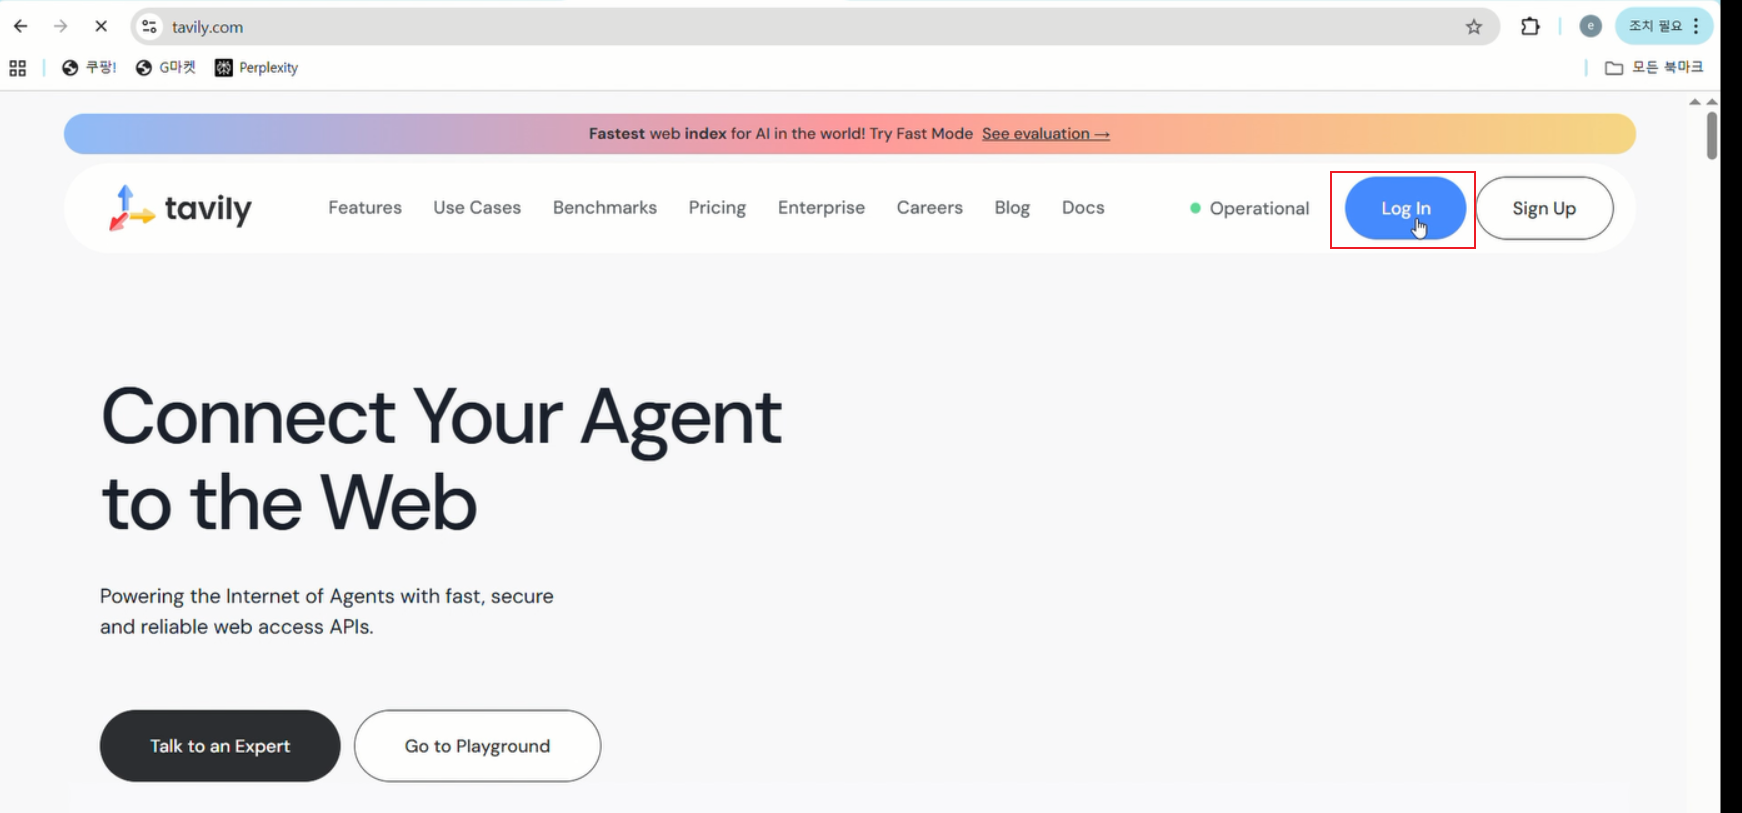

- '+' 버튼 클릭해서 API KEY 생성

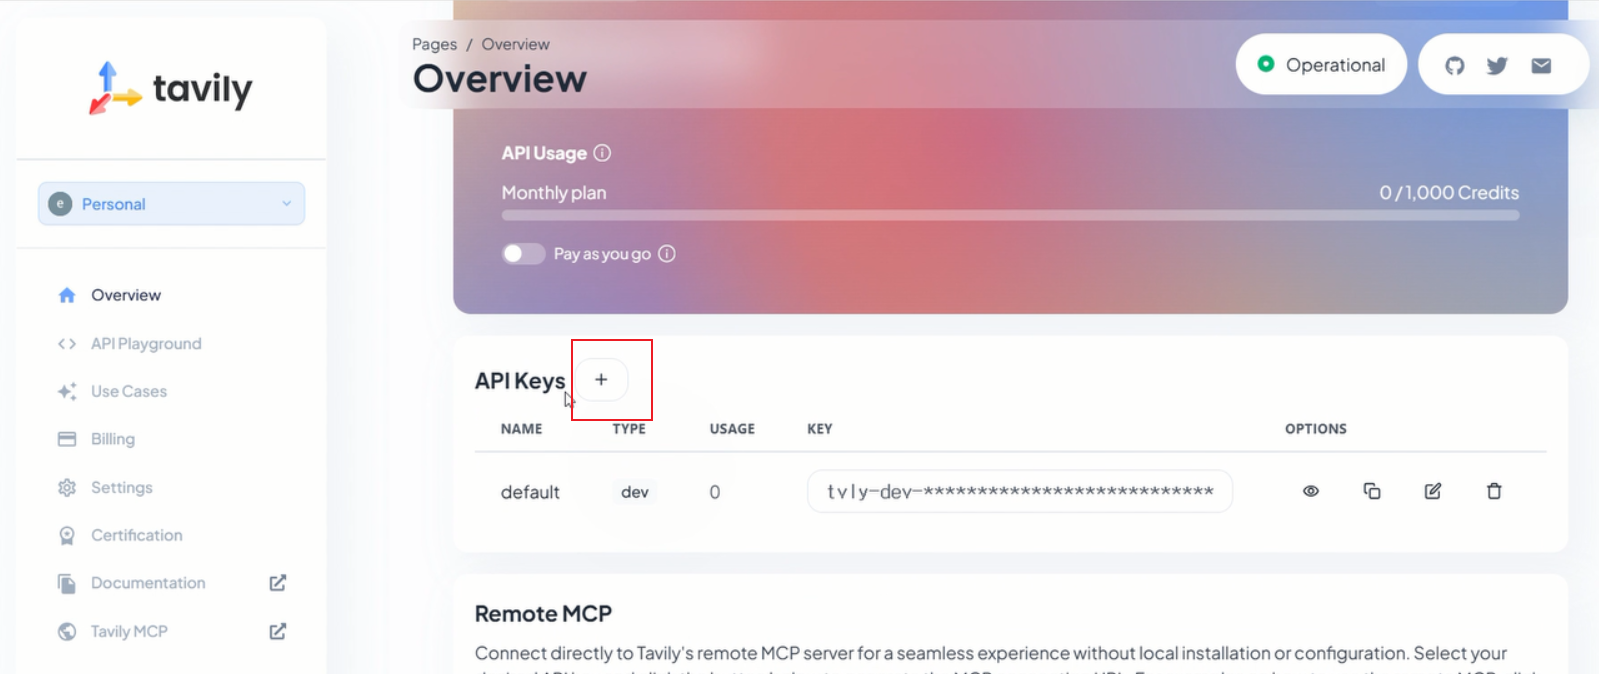

- Key 이름 작성 후 Create

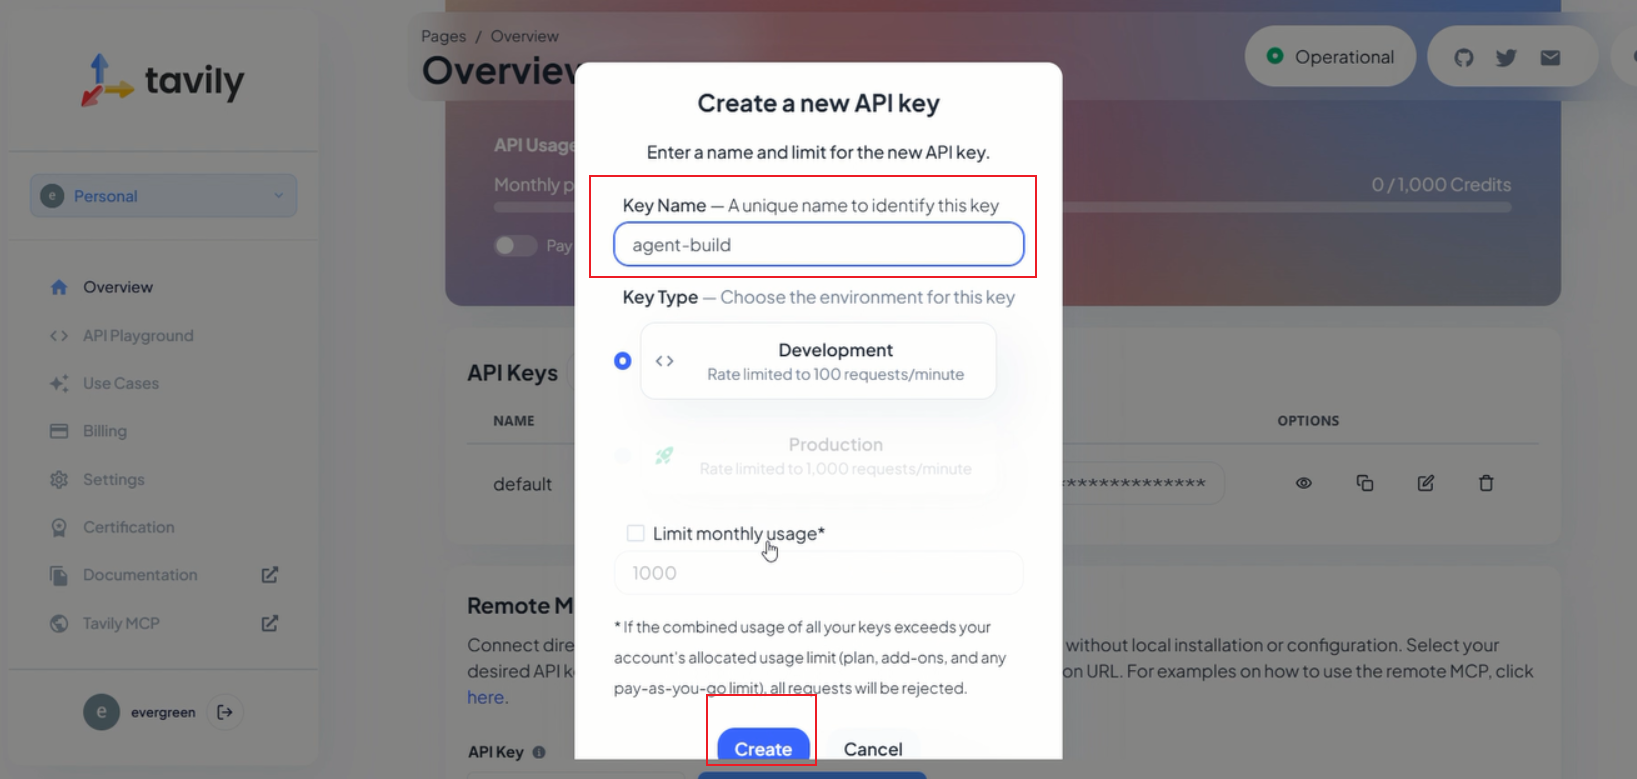

- 생성한 API KEY에 대해 복사

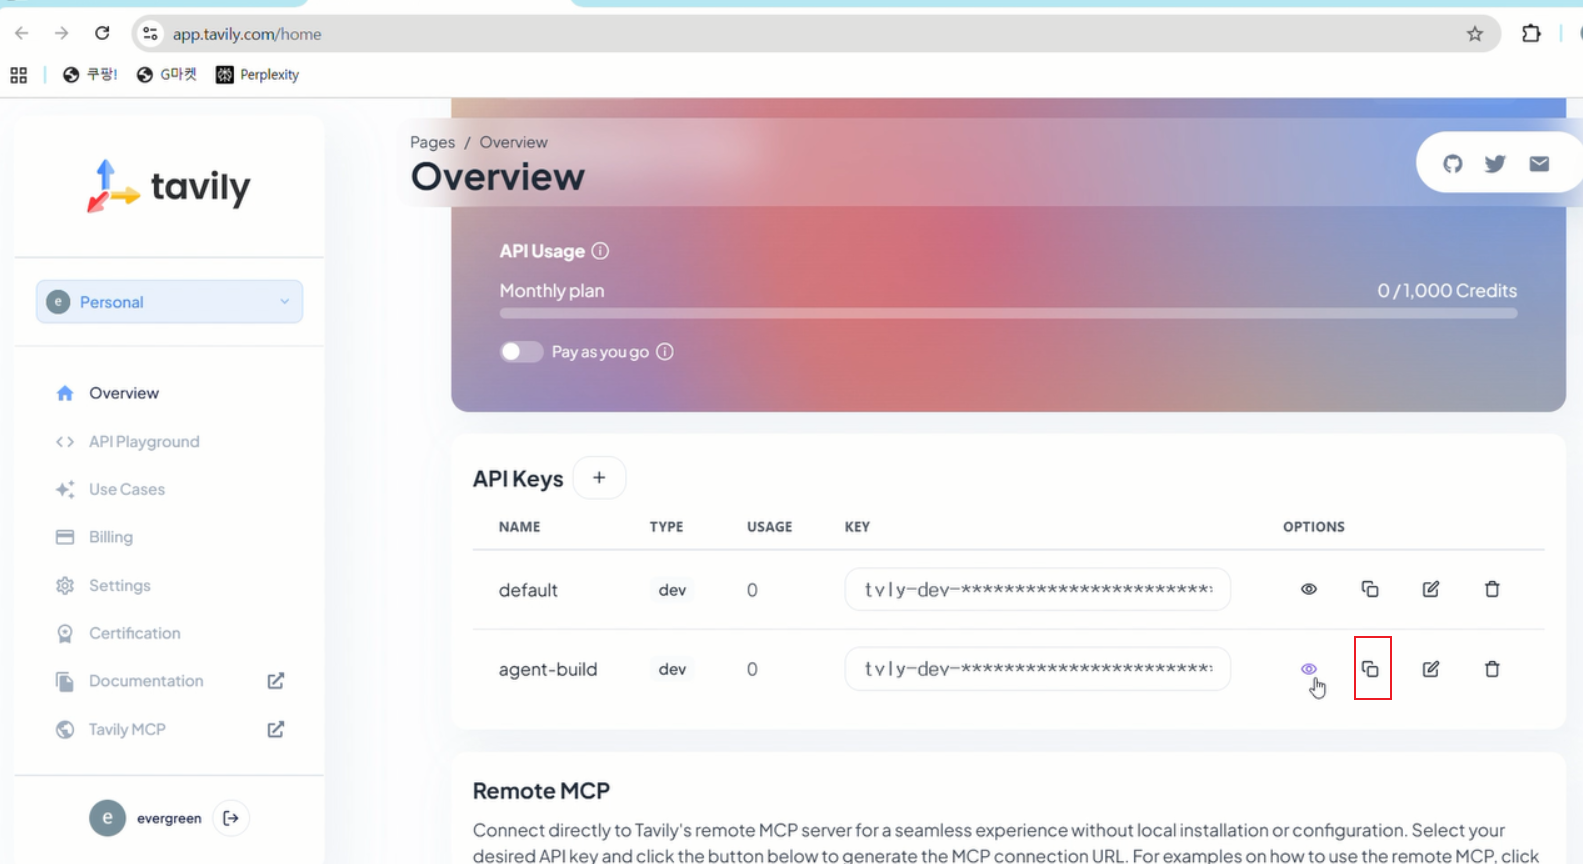

- Colab의 보안 비밀에 넣기

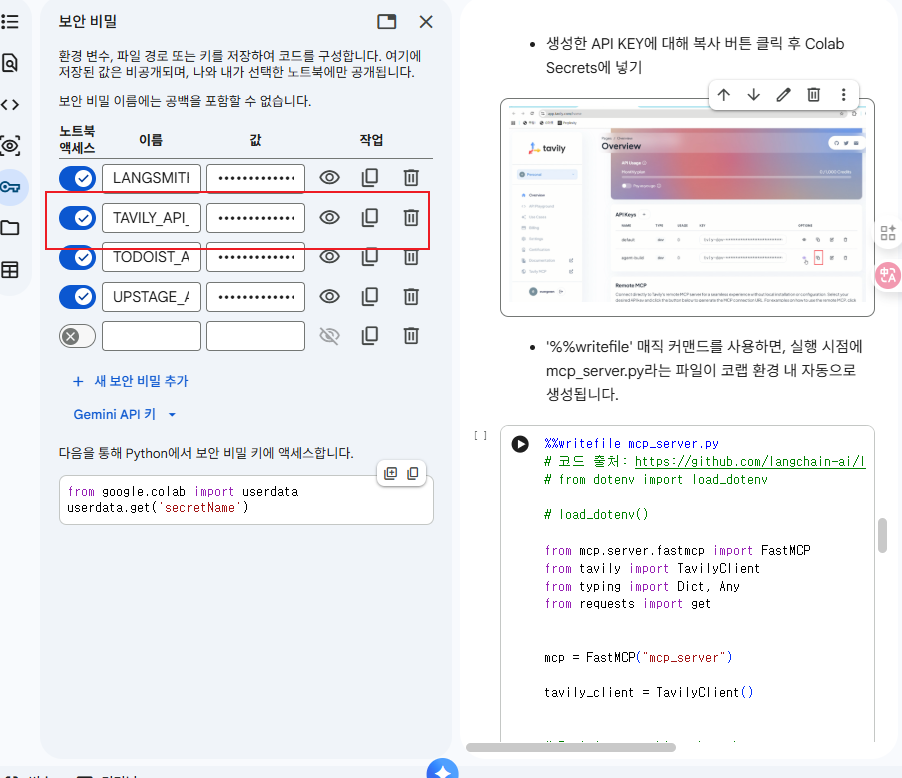

- '%%writefile' 매직 커맨드를 사용하면, 실행 시점에 mcp_server.py라는 파일이 코랩 환경 내 자동으로 생성됩니다.

In [12]:
%%writefile mcp_server.py
# 코드 출처: https://github.com/langchain-ai/lca-lc-foundations/blob/main/notebooks/module-2/resources/2.1_mcp_server.py

from mcp.server.fastmcp import FastMCP
from tavily import TavilyClient
from typing import Dict, Any
from requests import get


mcp = FastMCP("mcp_server")

tavily_client = TavilyClient()


# Tool for searching the web
@mcp.tool()
def search_web(query: str) -> Dict[str, Any]:
    """Search the web for information"""

    results = tavily_client.search(query)

    return results


# Resources - provide access to langchain-ai repo files
@mcp.resource("github://langchain-ai/langchain-mcp-adapters/blob/main/README.md")
def github_file():
    """
    Resource for accessing langchain-ai/langchain-mcp-adapters/README.md file

    """
    url = f"https://raw.githubusercontent.com/langchain-ai/langchain-mcp-adapters/refs/heads/main/README.md"
    try:
        resp = get(url)
        return resp.text
    except Exception as e:
        return f"Error: {str(e)}"


# Prompt template
@mcp.prompt()
def prompt():
    """Analyze data from a langchain-ai repo file with comprehensive insights"""
    return """
    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.

    You can use the following tools/resources to answer user questions:
    - search_web: Search the web for information
    - github_file: Access the langchain-ai repo files

    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I'm sorry, I can only answer questions about LangChain, LangGraph and LangSmith."

    You may try multiple tool and resource calls to answer the user's question.

    You may also ask clarifying questions to the user to better understand their question.
    """

if __name__ == "__main__":
    mcp.run(transport="stdio")

Writing mcp_server.py


- 현재 경로의 mcp_server.py 를 실행시킵니다.

In [13]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "local_server": {
                "transport": "stdio",
                "command": "python",
                "args": ["mcp_server.py"],
                "env": {
                    "TAVILY_API_KEY": os.environ.get("TAVILY_API_KEY")
                }
            }
    }
)

In [14]:
# get tools
mcp_tools = await client.get_tools()

# get resources
mcp_resources = await client.get_resources("local_server")

# get prompts
mcp_prompt = await client.get_prompt("local_server", "prompt")
mcp_prompt = mcp_prompt[0].content

In [15]:
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
    ToolMessage,
)

from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent

resource_context = "\n".join([
    f"[{blob.metadata.get('uri')}]: {blob.as_string()}"
    for blob in mcp_resources
])

system_content = ""
for msg in mcp_prompt:
    if isinstance(msg, SystemMessage):
        system_content = msg.content
        break

final_system_prompt = f"""
{system_content}

## Available Context:
{resource_context}
"""

agent_with_local_mcp = create_agent(
    model=llm,
    tools=mcp_tools,
    system_prompt=final_system_prompt,
    checkpointer=InMemorySaver()
)

In [16]:
config = {"configurable": {"thread_id": "12"}}

response = await agent_with_local_mcp.ainvoke(
    {"messages": [HumanMessage(content="langchain-mcp-adapters 라이브러리의 최신 내용 대해 알려줘")]},
    config=config
)

In [17]:
rprint(response)

{
    'messages': [
        HumanMessage(
            content='langchain-mcp-adapters 라이브러리의 최신 내용 대해 알려줘',
            additional_kwargs={},
            response_metadata={},
            id='299b754a-f201-4707-9446-53212b98f545'
        ),
        AIMessage(
            content='현재 제공된 컨텍스트([github://langchain-ai/langchain-mcp-adapters/blob/main/README.md])에 
따르면, `langchain-mcp-adapters` 라이브러리의 최신 주요 내용은 다음과 같습니다:\n\n1. **핵심 기능**  \n   - 
Anthropic MCP 도구를 LangChain/LangGraph 에이전트와 호환되는 도구로 변환\n   - 여러 MCP 서버에 동시 연결 및 도구 
로드 지원\n\n2. **주요 업데이트 사항**  \n   - **Streamable HTTP 지원**: MCP 2025-03-26 스펙의 스트리밍 HTTP 전송 
방식 통합\n   - **인증 헤더 전달**: HTTP/SSE 전송 시 `Authorization` 등 커스텀 헤더 추가 가능\n   - **LangGraph 
통합 강화**: `StateGraph`와 직접 연동 가능한 예제 제공\n   - **다중 서버 관리**: `MultiServerMCPClient`로 서로 다른
전송 방식(stdio/http)의 서버 동시 연결\n\n3. **사용 시나리오**  \n   - 로컬 stdio 서버(수학 계산)와 원격 HTTP 
서버(날씨 정보)를 동시에 사용하는 에이전트 구성\n   - LangGraph API 서버에서 MCP 도구 활용 시 주의사항 명시(stdio 
전송의 웹 서버 사용 제한)\n\n4. **설치 및 의존성**  \n   ```bash\n   pip install langchain-mcp-adapters\n   ```\n  
- 필수 의존성: `langchain[openai]`, `langgraph`\n\n5. **최신 예제**  \n   - [Streamable HTTP 서버 
예제](examples/servers/streamable-http-stateless/)\n   - LangGraph API 서버와의 통합 가이드\n\n> ⚠️ **주의사항**: 
문서에 명시된 대로 stdio 전송은 웹 서버 환경에서 사용 시 보안/안정성 검토가 필요합니다. HTTP 전송이 일반적으로 
권장됩니다.\n\n이 정보는 2025년 3월 26일 기준 MCP 스펙을 반영한 최신 내용을 포함하고 있습니다. 추가 업데이트는 
[공식 GitHub 저장소](https://github.com/langchain-ai/langchain-mcp-adapters)에서 확인할 수 있습니다.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 400,
                    'prompt_tokens': 3026,
                    'total_tokens': 3426,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'solar-pro2-251215',
                'system_fingerprint': None,
                'id': '75f256ff-d2b1-4314-8e59-11bf3781f0ac',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019bbad3-fbad-76b2-8eed-7b1647b7a7da-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 3026,
                'output_tokens': 400,
                'total_tokens': 3426,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [18]:
response = await agent_with_local_mcp.ainvoke(
    {"messages": [HumanMessage(content="2025년 손흥민 근황을 검색해줘")]},
    config=config
)

In [ ]:
# rprint(response)